<a href="https://colab.research.google.com/github/SS-Actinium/Project-Music-Genre-Classification/blob/main/Project_Music_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Create the Data directory
!mkdir -p Data

# Download the GTZAN dataset from the Hugging Face mirror
!wget -O genres.tar.gz https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz

# Extract the downloaded file into the Data folder
!tar -xzf genres.tar.gz -C Data/

# Rename the extracted folder to match the path in our script
!mv Data/genres Data/genres_original

# Verify the folders are there (you should see 10 genre folders listed)
!ls Data/genres_original

--2026-07-29 10:41:44--  https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz
Resolving huggingface.co (huggingface.co)... 3.171.171.65, 3.171.171.128, 3.171.171.104, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.65|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/622f5743bc2a392eaf21b43b/900ade7929618e8a0fafb2f639f0ed1620cdf475c5fea56f874a69d900b3c5df?X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27genres.tar.gz%3B+filename%3D%22genres.tar.gz%22%3B&user_id=public&response-content-type=application%2Fgzip&Expires=1785325304&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjIyZjU3NDNiYzJhMzkyZWFmMjFiNDNiLzkwMGFkZTc5Mjk2MThlOGEwZmFmYjJmNjM5ZjBlZDE2MjBjZGY0NzVjNWZlYTU2Zjg3NGE2OWQ5MDBiM2M1ZGZcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomdXNlcl9pZD1wdWJsaWMmcmVzcG9uc2UtY29udGVud

In [25]:
pip install librosa tensorflow scikit-learn matplotlib numpy

In [26]:
import os
import math
import json
import librosa
import numpy as np

DATASET_PATH = "Data/genres_original" # Path to your GTZAN folder
JSON_PATH = "data.json"
SAMPLE_RATE = 22050
DURATION = 30 # Measured in seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

def save_mfcc(dataset_path, json_path, num_segments=10, n_mfcc=13, n_fft=2048, hop_length=512):
    # Dictionary to store mapping, labels, and MFCCs
    data = {
        "mapping": [],
        "labels": [],
        "mfcc": []
    }

    samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
    # Correct calculation for expected MFCC vectors based on librosa's output
    expected_mfcc_vectors = 1 + (samples_per_segment - n_fft) // hop_length

    # Loop through all genre sub-folders
    for i, (dirpath, dirnames, filenames) in enumerate(os.walk(dataset_path)):
        if dirpath is not dataset_path:
            genre_label = dirpath.split("/")[-1]
            data["mapping"].append(genre_label)
            print(f"Processing genre: {genre_label}")

            for f in filenames:
                # Librosa occasionally struggles with a corrupted file in GTZAN (jazz.00054.wav)
                # Also skip macOS-generated hidden files that start with '._'
                if f.endswith('.wav') and f != "jazz.00054.wav" and not f.startswith('._'):
                    file_path = os.path.join(dirpath, f)
                    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                    # Process file into segments
                    for s in range(num_segments):
                        start = samples_per_segment * s
                        finish = start + samples_per_segment

                        # Extract segment, padding if it's too short due to end of track
                        segment = signal[start:finish]
                        if len(segment) < samples_per_segment:
                            pad_width = samples_per_segment - len(segment)
                            segment = np.pad(segment, (0, pad_width), 'constant')

                        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_fft=n_fft, n_mfcc=n_mfcc, hop_length=hop_length)
                        mfcc = mfcc.T # Transpose to (n_frames, n_mfcc)

                        # Ensure MFCC array has the expected number of frames by padding or truncating
                        if len(mfcc) > expected_mfcc_vectors:
                            mfcc = mfcc[:expected_mfcc_vectors, :] # Truncate if too long
                        elif len(mfcc) < expected_mfcc_vectors:
                            # Pad with zeros if too short
                            pad_width = expected_mfcc_vectors - len(mfcc)
                            mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), 'constant')

                        # Now, mfcc will always have len(mfcc) == expected_mfcc_vectors
                        data["mfcc"].append(mfcc.tolist())
                        data["labels"].append(i - 1)

    # Save MFCCs to JSON file
    with open(json_path, "w") as fp:
        json.dump(data, fp)

# Run feature extraction
save_mfcc(DATASET_PATH, JSON_PATH, num_segments=10)

Processing genre: jazz
Processing genre: metal
Processing genre: hiphop
Processing genre: genres
Processing genre: jazz
Processing genre: metal
Processing genre: hiphop
Processing genre: rock
Processing genre: classical
Processing genre: disco
Processing genre: country
Processing genre: blues
Processing genre: pop
Processing genre: reggae
Processing genre: rock
Processing genre: classical
Processing genre: disco
Processing genre: country
Processing genre: blues
Processing genre: pop
Processing genre: reggae


In [28]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

def load_data(data_path):
    with open(data_path, "r") as fp:
        raw_data = json.load(fp)

    # Define the 10 canonical genres and create a mapping from genre name to ID (0-9)
    # The actual genres extracted from the dataset are:
    # blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock
    canonical_genres = sorted(list(set([g for g in raw_data["mapping"] if g not in ['genres']]))) # Filter out the spurious 'genres' label
    canonical_genre_to_id = {genre: i for i, genre in enumerate(canonical_genres)}

    X_filtered = []
    y_filtered = []

    # Iterate through the raw data and remap labels to the canonical IDs
    for i, mfcc_feature in enumerate(raw_data["mfcc"]):
        original_label_index = raw_data["labels"][i]
        original_genre_name = raw_data["mapping"][original_label_index]

        if original_genre_name in canonical_genre_to_id:
            X_filtered.append(mfcc_feature)
            y_filtered.append(canonical_genre_to_id[original_genre_name])

    X = np.array(X_filtered)
    y = np.array(y_filtered)

    # Return the filtered data and the canonical genre mapping
    return X, y, canonical_genres

# Load the prepared data
X, y, mapping = load_data(JSON_PATH)

# Train/validation split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CNNs require a 3D array input (time steps, MFCCs, channels). We add the channel dimension.
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
input_shape = (X_train.shape[1], X_train.shape[2], 1)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    Conv2D(64, (2, 2), activation='relu'),
    MaxPooling2D((2, 2), strides=(2, 2), padding='same'),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3), # Helps prevent overfitting
    Dense(len(mapping), activation='softmax') # Use the length of the *corrected* mapping
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
print("Training the CNN...")
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=30)

# Save the trained model and the mapping configuration
model.save("genre_classifier.h5")
with open("genre_mapping.json", "w") as f:
    json.dump(mapping, f)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the CNN...
Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 118ms/step - accuracy: 0.3196 - loss: 1.9404 - val_accuracy: 0.4289 - val_loss: 1.5581
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 148ms/step - accuracy: 0.4293 - loss: 1.5537 - val_accuracy: 0.4962 - val_loss: 1.3575
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 147ms/step - accuracy: 0.5199 - loss: 1.3062 - val_accuracy: 0.5848 - val_loss: 1.1267
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 149ms/step - accuracy: 0.5803 - loss: 1.1571 - val_accuracy: 0.6399 - val_loss: 0.9982
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 166ms/step - accuracy: 0.6244 - loss: 1.0442 - val_accuracy: 0.6839 - val_loss: 0.9014
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 147ms/step - accuracy: 0.6709 - loss: 0.9356 - val_accuracy: 0.6902 - val_loss: 0.8622
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - accuracy: 0.6989 - loss: 0.8533 - val_accuracy: 0.7460 - val_loss: 0.7301
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 127ms/step - accura

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def predict_genre_with_spectrogram(audio_path, model_path="genre_classifier.h5", mapping_path="genre_mapping.json"):
    # Load model and mapping dictionary
    model = tf.keras.models.load_model(model_path)
    with open(mapping_path, "r") as f:
        mapping = json.load(f)

    # Preprocessing parameters
    SAMPLE_RATE = 22050
    signal, sr = librosa.load(audio_path, sr=SAMPLE_RATE)

    # We analyze the first 3 seconds of the audio file to match training inputs
    samples_per_segment = int(SAMPLE_RATE * 3)
    segment = signal[:samples_per_segment]

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_fft=2048, n_mfcc=13, hop_length=512)
    mfcc = mfcc.T

    # Reshape and predict
    X = mfcc[np.newaxis, ..., np.newaxis]
    predictions = model.predict(X)

    predicted_index = np.argmax(predictions, axis=1)[0]
    confidence_score = predictions[0][predicted_index]
    genre = mapping[predicted_index]

    print("="*40)
    print(f"Audio File: {audio_path}")
    print(f"Predicted Genre: **{genre.upper()}**")
    print(f"Confidence Score: {confidence_score:.2%}")
    print("="*40)

    # Generate Mel Spectrogram Visualization
    plt.figure(figsize=(10, 4))
    mel_spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

    librosa.display.specshow(log_mel_spectrogram, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel Spectrogram - Predicted: {genre}')
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Audio File: Data/genres_original/rock/rock.00000.wav
Predicted Genre: **ROCK**
Confidence Score: 84.07%


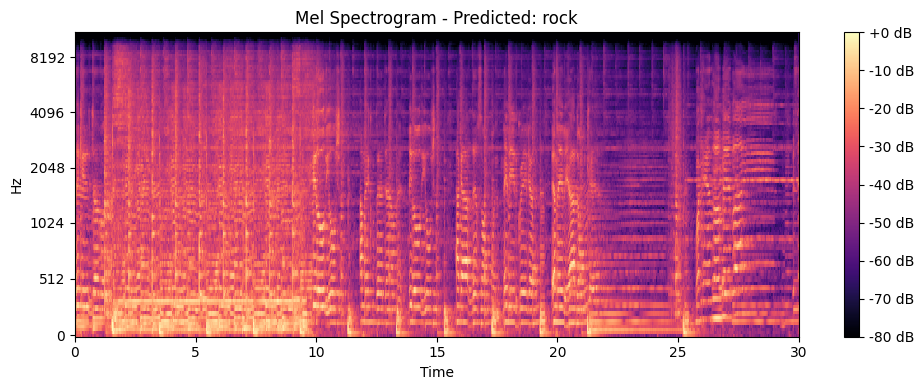

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
Audio File: Data/genres_original/jazz/jazz.00001.wav
Predicted Genre: **JAZZ**
Confidence Score: 98.81%


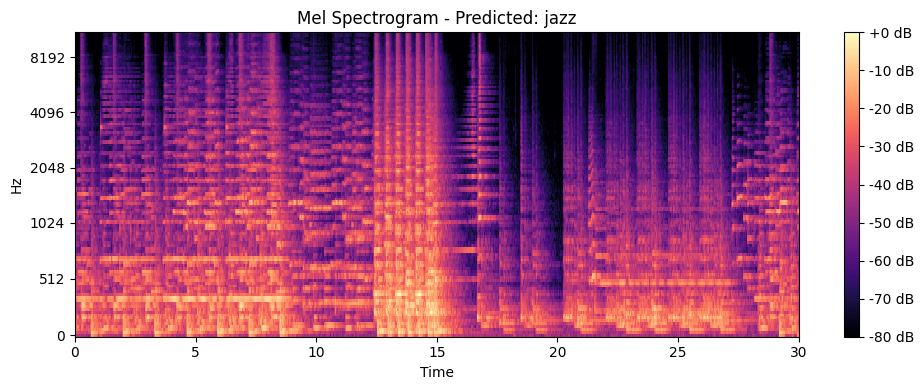

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
Audio File: Data/genres_original/hiphop/hiphop.00002.wav
Predicted Genre: **HIPHOP**
Confidence Score: 100.00%


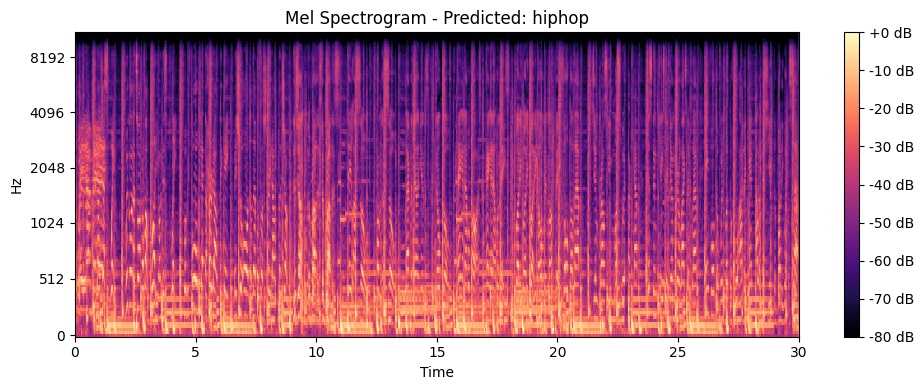

In [31]:
# Test with a Rock track
predict_genre_with_spectrogram("Data/genres_original/rock/rock.00000.wav")

# Test with a Jazz track
predict_genre_with_spectrogram("Data/genres_original/jazz/jazz.00001.wav")

# Test with a Hip-Hop track
predict_genre_with_spectrogram("Data/genres_original/hiphop/hiphop.00002.wav")

Download complete!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Audio File: external_test_song.mp3
Predicted Genre: **REGGAE**
Confidence Score: 59.38%


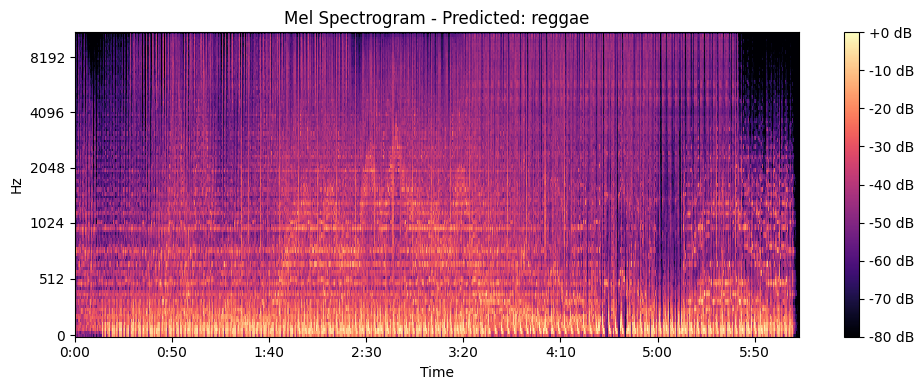

In [32]:
import urllib.request

# Royalty-free sample audio URL
test_url = "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3"
test_filename = "external_test_song.mp3"

# Download the file
print("Downloading test song...")
urllib.request.urlretrieve(test_url, test_filename)
print("Download complete!")

# Predict using Cell 5
predict_genre_with_spectrogram(test_filename)

In [30]:
# Save the trained model in the native Keras format
model.save("genre_classifier.keras")

# Save the mapping configuration
with open("genre_mapping.json", "w") as f:
    json.dump(mapping, f)